# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Importing Dataset

In [ ]:
df = pd.read_csv("ecg.csv")

print("Shape:", df.shape)
df.head()

Shape: (4997, 141)


,-0.11252183,-2.8272038,-3.7738969,-4.3497511,-4.376041,-3.4749863,-2.1814082,-1.8182865,-1.2505219,-0.47749208,...,0.79216787,0.93354122,0.79695779,0.57862066,0.2577399,0.22807718,0.12343082,0.92528624,0.19313742,1.0
0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
1,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
2,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
3,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
4,-1.507674,-3.574550,-4.478011,-4.408275,-3.321242,-2.105171,-1.481048,-1.301362,-0.498240,-0.286928,...,1.089068,0.983369,1.014124,0.952629,0.749326,1.007076,1.634990,1.493365,-0.783134,1.0


# Cleaning Column Names

In [ ]:
df.columns = df.columns.str.strip()

# Target Variable Analysis

In [ ]:
target = df.columns[-1]

print("Target Column:", target)
df[target].value_counts()

Target Column: 1.0


,count
1.0,
1.0,2918
0.0,2079


# Handling Missing Values

In [ ]:
df.isnull().sum()

,0
-0.11252183,0
-2.8272038,0
-3.7738969,0
-4.3497511,0
-4.376041,0
...,...
0.22807718,0
0.12343082,0
0.92528624,0
0.19313742,0


# Visualizing Target Classes

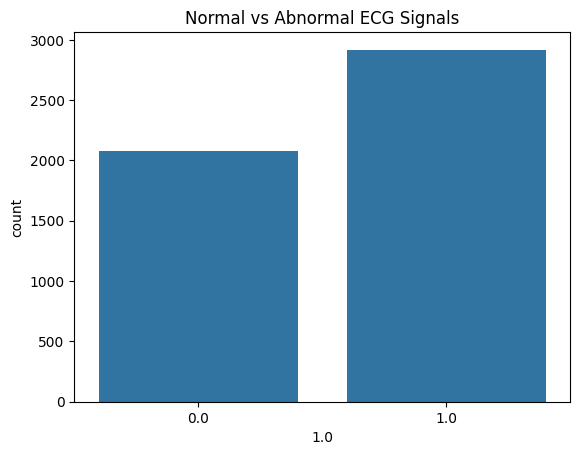

In [ ]:
sns.countplot(x=target, data=df)
plt.title("Normal vs Abnormal ECG Signals")
plt.show()

# Splitting Features and Target

In [ ]:
X = df.drop(target, axis=1)
y = df[target]

# Data Preprocessing

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Splitting Dataset into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest Classifier

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.989


# Model Prediction

In [ ]:
y_pred = model.predict(X_test)

# Model Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.982

Confusion Matrix:
[[400  10]
 [  8 582]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       410
         1.0       0.98      0.99      0.98       590

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



# Confusion Matrix Visualization

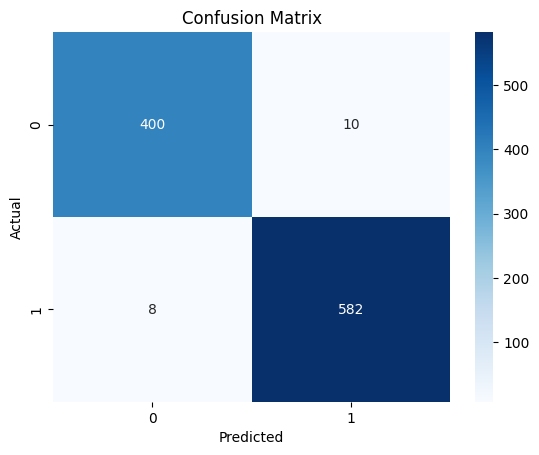

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Data Visualization (Scatter Plot)

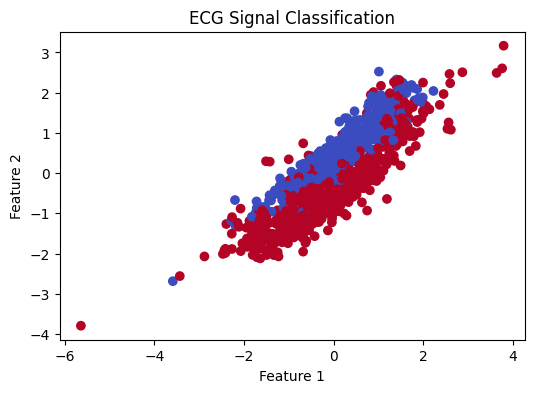

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm')

plt.title("ECG Signal Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()